In [1]:


#Importing libraries to import classes
import sys
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import random
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath('..'))
from nfl_cb_main import dsCompile, featEng, Classifiers, TTD, ProbabilityCalibrator


pd.set_option('display.max_columns', None)

In [2]:

#Loading the data in and filtering down
comp = dsCompile()

df = comp.dataset_loader()

print(df.shape)

df = df[['season','play_id','game_id', 'game_date', 'home_team.x', 'away_team.x', 'season_type.x',
         'city','chiefs_score.x', 'opp_score.x', 'tot_scr', 'chiefs_score.y', 'opp_score.y', 'score_diff',
         'chiefs_win','quarter_seconds_remaining','quarter_elapsed',
         'cum_play_count', 'cum_qb_hits', 'cum_sacks','cum_penalty', 'cum_penalty_yards', 'cum_tfl', 'cum_3dc', 'cum_3df',
       'cum_4dc', 'cum_4df', 'cum_rush_attmpt', 'cum_pass_attmpt','cum_incmpl_pass', 'cum_ydsgain','qtr1', 'qtr2',
       'qtr3', 'qtr4', 'ot',
       'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum','roof', 'surface']].rename(columns={
           'home_team.x':'home_team',
           'away_team.x':'away_team',
           'season_type.x':'season_type',
           'chiefs_score.x':'game_chiefs_scr',
           'tot_scr':'game_tot_scr',
           'opp_score.x':'game_opps_scr',
           'chiefs_score.y':'cum_chiefs_scr',
           'opp_score.y':'cum_opps_scr',
           'score_diff':'cum_score_dif'
       })


#Performing feature engineering
categorical_vars = ['season_type','city','opp_team','roof', 'surface']

fteng = featEng(cat_cols=categorical_vars)

df = fteng.feature_addition(data=df)

df = df[df['quarter'] != 5]


#Only keeping the few plays around the end of the quarter so the model can generalize better
df = (
    df.sort_values(['season', 'game_id', 'quarter', 'cum_play_count_by_quarter'])
      .groupby(['season', 'game_id', 'quarter'], group_keys=False)
      .apply(lambda g: g.nlargest(7, 'cum_play_count_by_quarter'))
      .sort_values(['season', 'game_id', 'quarter', 'cum_play_count_by_quarter'])
      .reset_index(drop=True)
)


#Filtering down to mainly just the derived features
df = df[['season',
         'season_type',
         'city',
         'tot_cum_scor',
         'cum_score_dif',
         'chiefs_win',
         'quarter_elapsed','cum_play_count'
         ,'cum_ydsgain','opp_team','quarter','game_velocity','rush_ratio','pass_ratio','incomplete_pass_rate',
         'scoring_efficiency','3rd_down_efficiency','4th_down_efficiency','avg_penalty_cost','avg_penalty_risk','qb_risk',
         'score_momentum','yards_per_play','sack_rate','tfl_rate','game_clock_pressure',
         'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum','roof','surface']]


#Splitting into independent and dependent variables
X_cols = [col for col in df.columns if col not in ['chiefs_win','season']]
y_col = 'chiefs_win'

#Returning a list of all years
all_years = sorted(df['season'].unique())
print(all_years)

#Train/test fold metrics
n_folds = 10
test_size = 4
threshold = 0.6


#Creating random unique combinations of the test years for validation
random.seed(42)
test_folds = random.sample(list(combinations(all_years, test_size)), n_folds)

print(test_folds)

Path to .env file: /Users/ethanparks/Desktop/repos/nfl-crystal-ball/nfl_cb_main/../.env
FILEPATH: /Users/ethanparks/Desktop/repos/pbp_compiled3.csv
(23925, 57)
[2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[(2012, 2019, 2021, 2022), (2009, 2012, 2020, 2024), (2009, 2010, 2015, 2021), (2014, 2015, 2020, 2023), (2010, 2012, 2016, 2017), (2010, 2011, 2016, 2021), (2010, 2011, 2012, 2015), (2009, 2013, 2021, 2023), (2014, 2015, 2018, 2022), (2009, 2012, 2017, 2020)]


/var/folders/bn/2j7_jm8s3rj0wj3v461ybxdw0000gn/T/ipykernel_60490/764259434.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(7, 'cum_play_count_by_quarter'))


In [3]:


fold_results = []
all_quarter_metrics = []
all_test_preds = []

#Loops goes through the list of test folds and years in each fold
for i, test_years in enumerate(test_folds, start=1):
    #Ensures that the years between train/test do not overlap
    test_years = list(test_years)
    train_years = [y for y in all_years if y not in test_years]

    print(f"\n Fold {i}")
    print(f"Train Years Used: {sorted(train_years)}")
    print(f"Test Years Used:  {sorted(test_years)}")

    # Fit encoder on training seasons only; transform test with that encoder
    train_df = df[df['season'].isin(train_years)].copy()
    test_df = df[df['season'].isin(test_years)].copy()
    fold_fteng = featEng(cat_cols=categorical_vars)
    train_df = fold_fteng.cat_transform(train_df)
    test_df = fold_fteng.transform_new(test_df)
    fold_df = pd.concat([train_df, test_df], ignore_index=True)

    #Instantiates XGBoost classifier with a moderately complex structure
    clss = Classifiers()
    chiefs_xgb = clss.xgb(
        scale_pos_weight=1,
        n_estimators=100,
        max_depth=7,
        learning_rate=0.05,
        reg_alpha=0.1,
        reg_lambda=2.0,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )

    #Instatiates train/dev/test splitting for each fold loop
    ttd = TTD(model_type='bin-xgb',model=chiefs_xgb)
    #Dev sets are not created due to k-fold validation method
    X_train, _, X_test, y_train, _, y_test = ttd.ttd_year_splits(
        fold_df,
        x_col=X_cols,
        y_col='chiefs_win',
        time_col='season',
        train_seasons=train_years,
        dev_seasons=None,
        test_seasons=test_years
    )
    
    #Model fit for training
    chiefs_xgb.fit(X_train, y_train)

    #Calibrate on 20% held-out slice of training data
    _, X_cal, _, y_cal = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    y_cal_proba = chiefs_xgb.predict_proba(X_cal)[:, 1]
    calibrator = ProbabilityCalibrator(method='platt')
    calibrator.fit(y_cal, y_cal_proba)

    #Class predictions made on calibrated outcome probabilities
    y_proba_raw = chiefs_xgb.predict_proba(X_test)[:, 1]
    y_proba = calibrator.calibrate(y_proba_raw)
    y_pred = (y_proba >= threshold).astype(int)

    #Summary of common metrics by fold
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    #Summary of class-specific metrics
    prec_win = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_win = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    prec_loss = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec_loss = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

    #Appending the results to a single summary for each fold loop
    fold_results.append({
        'Fold': i,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Precision_win': prec_win,
        'Recall_win': rec_win,
        'Precision_loss': prec_loss,
        'Recall_loss': rec_loss,
        'brier_score_raw': calibrator.brier_score(y_test, y_proba_raw),
        'brier_score_calibrated': calibrator.brier_score(y_test, y_proba),
        'n_test_samples': len(y_test)
    })

    if i == n_folds:
        final_y_test = y_test
        final_y_proba_cal = y_proba
        final_calibrator = calibrator

    #Creating a dataset of the years of each fold loop, addimg the model probabilities and prediction, and the associated quarter
    fold_test_df = test_df.copy().reset_index(drop=True)
    fold_test_df['y_true'] = y_test.values
    fold_test_df['y_pred'] = y_pred
    fold_test_df['y_proba'] = y_proba
    fold_test_df['quarter'] = fold_test_df['quarter'].astype(str)


    #Add confidence score to answer statistical question
    fold_test_df['confidence'] = abs(2 * fold_test_df['y_proba'] - 1)

    #Appending each loop for later comparison
    all_test_preds.append(fold_test_df)

    #Determining the median confidence by quarter
    quarter_confidence = fold_test_df.groupby('quarter')['confidence'].median()
    print("Average Model Confidence by Quarter:")
    print(quarter_confidence)


    metrics_by_qtr = []
    #Final loop through each fold dataset in determining the class-specific metrics by quarter
    for qtr, group in fold_test_df.groupby('quarter'):

        acc_q = accuracy_score(group['y_true'], group['y_pred'])
        overall_f1 = f1_score(group['y_true'], group['y_pred'], average='weighted')

        prec_win = precision_score(group['y_true'], group['y_pred'], pos_label=1, zero_division=0)
        rec_win = recall_score(group['y_true'], group['y_pred'], pos_label=1, zero_division=0)
        f1_win = f1_score(group['y_true'], group['y_pred'], pos_label=1, zero_division=0)

        prec_loss = precision_score(group['y_true'], group['y_pred'], pos_label=0, zero_division=0)
        rec_loss = recall_score(group['y_true'], group['y_pred'], pos_label=0, zero_division=0)
        f1_loss = f1_score(group['y_true'], group['y_pred'], pos_label=0, zero_division=0)


        metrics_by_qtr.append({
            'Fold': i,
            'Quarter': qtr,
            'Accuracy': acc_q,
            'F1':overall_f1,
            'Precision_win': prec_win,
            'Recall_win': rec_win,
            'Precision_loss': prec_loss,
            'Recall_loss': rec_loss,
            'F1_win':f1_win,
            'F1_loss':f1_loss,
            'n_test_samples': len(group)
        })

    all_quarter_metrics.append(pd.DataFrame(metrics_by_qtr))

# Fit final encoder on full dataset and persist for inference
os.makedirs('../models', exist_ok=True)
final_fteng = featEng(cat_cols=categorical_vars)
final_fteng.cat_transform(df)
final_fteng.save_encoder('../models/encoder.joblib')

final_calibrator.plot_calibration_curve(
    final_y_test,
    final_y_proba_cal,
    title='Calibration Curve (Final Fold)',
    save_path='../models/calibration_curve.png'
)

#After the loop finishes...

#Creates an aggregate dataset of the metrics for each fold
cv_results = pd.DataFrame(fold_results)
print(cv_results[0:5])

#Creates a quarter level eval dataset of all folds
quarter_eval_df = pd.concat(all_quarter_metrics, ignore_index=True)

#Creates a full dataset of test records and associated model outputs for each fold
combined_df = pd.concat(all_test_preds, ignore_index=True) 

#Summarizes the results by fold and quarter
print("\n Cross-Validation Fold Results:")
print(cv_results[[
    'Fold', 'Accuracy', 'Precision', 'Recall', 'F1',
    'Precision_win', 'Recall_win', 'Precision_loss', 'Recall_loss'
]])

print("\n Average Performance Across Folds:")
print(cv_results[[
    'Accuracy', 'Precision', 'Recall', 'F1',
    'Precision_win', 'Recall_win', 'Precision_loss', 'Recall_loss'
]].mean())

print(f"\nRaw Brier Score: {cv_results['brier_score_raw'].mean():.3f}")
print(f"Calibrated Brier Score: {cv_results['brier_score_calibrated'].mean():.3f}")
print("Baseline (always predict 0.5): 0.250")

print("\n Quarter-Level Metrics Averaged Across Folds:")
print(quarter_eval_df.groupby('Quarter')[
    ['Accuracy', 'F1', 'Precision_win', 'Recall_win', 'Precision_loss', 'Recall_loss','F1_win','F1_loss']
].mean())



#Statistical Comparison of Quarters

#Calculates the median confidence score for each quarter
q1 = combined_df[combined_df['quarter'] == '1']['confidence']
q2 = combined_df[combined_df['quarter'] == '2']['confidence']
q3 = combined_df[combined_df['quarter'] == '3']['confidence']
q4 = combined_df[combined_df['quarter'] == '4']['confidence']

print(f'\n Quarter 1 Median: {q1.median()}')
print(f'Quarter 2 Median: {q2.median()}')
print(f'Quarter 3 Median: {q3.median()}')
print(f'Quarter 4 Median: {q4.median()}')

#Calculates a unique game identifier for the statistical tests and the median confidence by game/quarter
combined_df['unq_game_id'] = combined_df.groupby(['season','opp_team','temperature_2m_max']).ngroup()
stat_df = combined_df.pivot_table(
    index='unq_game_id',
    columns='quarter',
    values='confidence',
    aggfunc='median'
).dropna()

#Performs a Friedman test across all quarters
Fr_stat, Fr_pval = friedmanchisquare(stat_df['1'], stat_df['2'], stat_df['3'], stat_df['4'])
print(f"Friedman test across quarters: Fr = {Fr_stat:.4f}, p = {Fr_pval:.4f}")

#Performs a Wilcoxon signed-rank test across just Q1 and Q2
W_stat, W_pval = wilcoxon(stat_df['1'], stat_df['2'])
print(f"Wilcoxon signed-rank test Q1 vs Q2: Fr = {W_stat:.4f}, p = {W_pval:.4f}")




 Fold 1
Train Years Used: [2009, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2018, 2020, 2023, 2024]
Test Years Used:  [2012, 2019, 2021, 2022]
Average Model Confidence by Quarter:
quarter
1    0.618827
2    0.737250
3    0.858977
4    0.899439
Name: confidence, dtype: float32

 Fold 2
Train Years Used: [2010, 2011, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023]
Test Years Used:  [2009, 2012, 2020, 2024]
Average Model Confidence by Quarter:
quarter
1    0.586082
2    0.633041
3    0.720266
4    0.855382
Name: confidence, dtype: float32

 Fold 3
Train Years Used: [2011, 2012, 2013, 2014, 2016, 2017, 2018, 2019, 2020, 2022, 2023, 2024]
Test Years Used:  [2009, 2010, 2015, 2021]
Average Model Confidence by Quarter:
quarter
1    0.654121
2    0.812877
3    0.890881
4    0.891891
Name: confidence, dtype: float32

 Fold 4
Train Years Used: [2009, 2010, 2011, 2012, 2013, 2016, 2017, 2018, 2019, 2021, 2022, 2024]
Test Years Used:  [2014, 2015, 2020, 2023]
Average Model Confidence b

## Median Model Confidence by Quarter

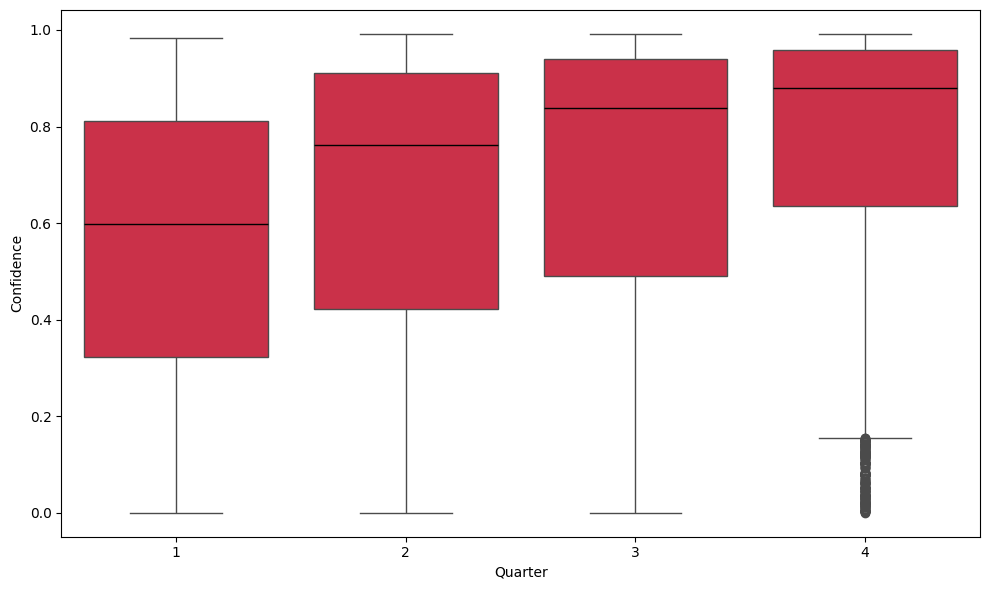

In [4]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='quarter', 
            y='confidence', 
            data=combined_df, 
            order=['1', '2', '3', '4'],
            color='#E31837',
            medianprops=dict(color='black'))

plt.xlabel('Quarter')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()


## Precision-Recall by Class for Each Fold

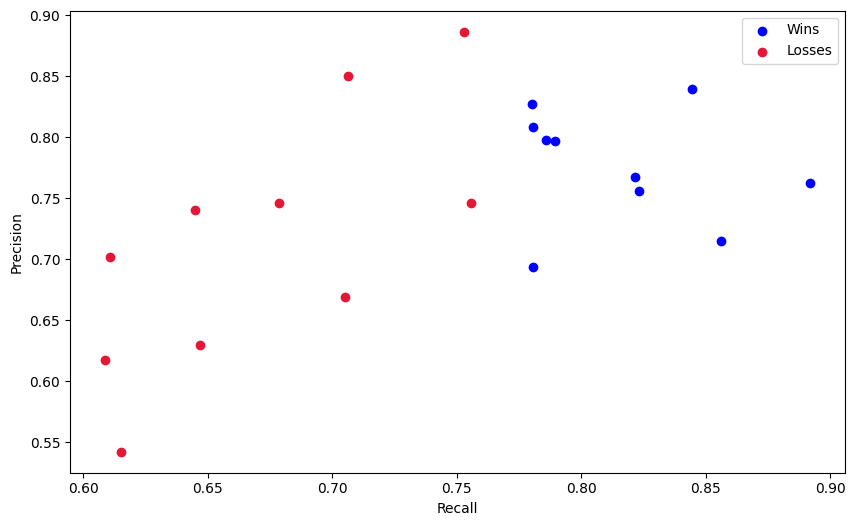

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(cv_results['Recall_win'], cv_results['Precision_win'], c='blue', label='Wins', alpha=1)
plt.scatter(cv_results['Recall_loss'], cv_results['Precision_loss'], c='#E31837', label='Losses', alpha=1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(False)
plt.legend()
plt.show()

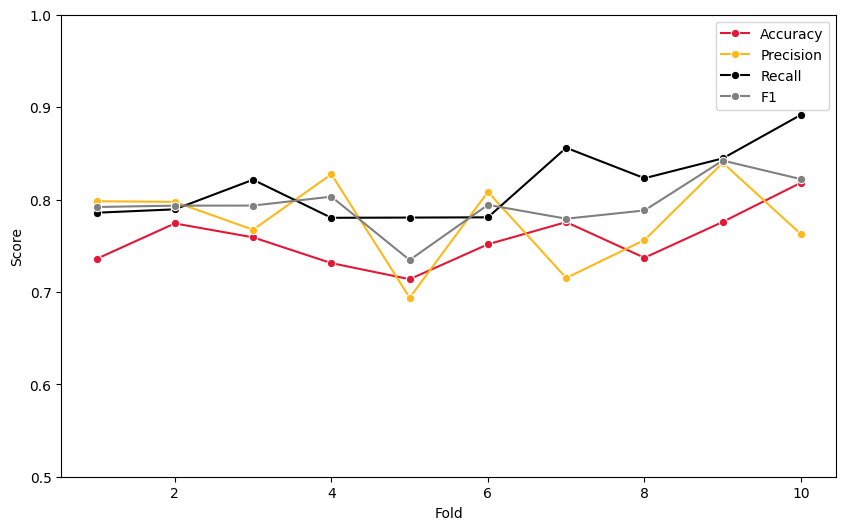

In [6]:

melted_df = cv_results.melt(id_vars='Fold', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'])

colorz = {
    'Accuracy': '#E31837',
    'Precision': '#FFB81C',
    'Recall': 'black',
    'F1': 'gray'
}


plt.figure(figsize=(10,6))
ax = sns.lineplot(data=melted_df, x='Fold', y='value', hue='variable', marker='o',palette=colorz)
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.grid(False)
ax.legend(title=None)
plt.show()

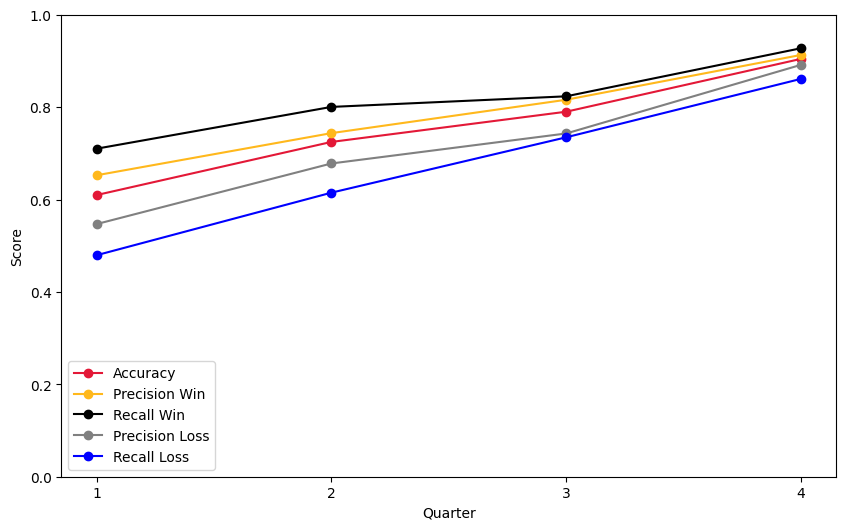

In [7]:


quarter_avg = quarter_eval_df.groupby('Quarter').mean().reset_index().rename(columns={
    'Accuracy': 'Accuracy',
    'Precision_win': 'Precision Win',
    'Recall_win': 'Recall Win',
    'Precision_loss':'Precision Loss',
    'Recall_loss':'Recall Loss'
})


metrics = ['Accuracy', 'Precision Win', 'Recall Win', 'Precision Loss', 'Recall Loss']

colorz = {
    'Accuracy': '#E31837',
    'Precision Win': '#FFB81C',
    'Recall Win': 'black',
    'Precision Loss': 'gray',
    'Recall Loss': 'blue'
}

plt.figure(figsize=(10,6))
for metric in metrics:
    plt.plot(quarter_avg['Quarter'], 
             quarter_avg[metric], 
             marker='o', 
             label=metric,
             color=colorz[metric])


plt.xlabel("Quarter")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.grid(False)
plt.legend()
plt.show()


